In [330]:
import pandas as pd
import numpy as np
import math

# google_trends = pd.read_csv("data/gold_google_trends_daily.csv")
data = pd.read_csv("../files/processed_data.csv")
match_context = pd.read_csv("../data/gold_match_context.csv")
# match_goals = pd.read_csv("data/gold_match_goals.csv")
match_tickets = pd.read_csv("../data/gold_match_tickets.csv")
# matches = pd.read_csv("data/gold_match.csv")
matches = pd.read_csv("../data/gold_match_with_league_standings.csv")
match_articles = pd.read_csv("../data/gold_belga_press_articles.csv", on_bad_lines="skip")

In [331]:
article_count = (match_articles
                 .groupby("match_id")["match_id"]
                 .value_counts()
                 .to_frame()
                 .reset_index()
                 .rename(columns={"count": "article_count"}))

In [332]:
matches["league_pos_home_inv"] = 19 - matches["league_position_home"]
matches["league_pos_away_inv"] = 19 - matches["league_position_away"]

In [333]:
tickets_sold_goals = match_tickets[["tickets_sold_total", "match_id", "seasonpass_holders"]]
matchdays = matches[["matchday", "match_id"]]
league_positions = matches[["league_pos_home_inv", "league_pos_away_inv", "match_id"]]


data = pd.merge(data, tickets_sold_goals, on="match_id")
data = pd.merge(data, matchdays, on="match_id")
data = pd.merge(data, league_positions, on="match_id")
data["away_team_code"] = data["away_team_code"].astype("category")


In [334]:
data["date"] = pd.to_datetime(data["date"])
data["month"] = data['date'].dt.month
data['month_cos'] = np.cos(2 * np.pi * data['month'] / 12)
# data = data.drop(["date", "month"], axis=1)

In [335]:
data["kickoff_time_local"] = pd.to_datetime(data["kickoff_time_local"], format='%H:%M:%S')
data["kickoff_time_local"] = pd.to_datetime(data["kickoff_time_local"], format='%H:%M:%S').dt.hour
data["is_18_hours"] = data["kickoff_time_local"] == 18
# data = data.drop("kickoff_time_local", axis=1)

In [336]:
data["is_sunday"] = data["weekday"] == 6
data["is_fri_hol"] = data["weekday"].isin([4, 5, 6])

0       (13.0, 18.0]
1      (8.333, 13.0]
2     (0.999, 8.333]
3      (8.333, 13.0]
4      (8.333, 13.0]
           ...      
66    (0.999, 8.333]
67      (13.0, 18.0]
68     (8.333, 13.0]
69    (0.999, 8.333]
70     (8.333, 13.0]
Name: league_pos_away_inv, Length: 71, dtype: category
Categories (3, interval[float64, right]): [(0.999, 8.333] < (8.333, 13.0] < (13.0, 18.0]]

In [337]:
n = 15
train_data = data[:-n]
test_data = data.tail(n)

In [338]:
avg_tickets_scanned = train_data.groupby("away_team_code")["tickets_scanned"].mean().to_frame().rename(columns={"tickets_scanned": "avg_tickets_scanned"})
match_context_part = match_context[["academic_week", "has_promotion", "match_id", "is_public_holiday"]]

In [339]:
train_data = pd.merge(train_data, match_context_part, on="match_id")
train_data = pd.merge(train_data, article_count, on="match_id")
train_data = pd.merge(train_data, avg_tickets_scanned, on="away_team_code")

test_data = pd.merge(test_data, match_context_part, on="match_id")
test_data = pd.merge(test_data, article_count, on="match_id")
test_data = pd.merge(test_data, avg_tickets_scanned, on="away_team_code")

In [340]:
train_data = train_data.drop("match_id", axis=1)
test_data = test_data.drop("match_id", axis=1)

In [355]:
train_data

,away_team_code,last_result_vs_opponent,kickoff_time_local,tickets_scanned,weekday,date,ohl_interest,tickets_sold_total,seasonpass_holders,matchday,...,month,month_cos,is_18_hours,is_sunday,is_fri_hol,academic_week,has_promotion,is_public_holiday,article_count,avg_tickets_scanned
0,WES,0,18,5565.0,5,2022-07-30,17.32,5025,4032,2.0,...,7,-8.660254e-01,True,False,True,48,False,False,36,6952.250000
1,CLU,-3,18,7440.0,6,2022-08-14,30.38,6263,4032,4.0,...,8,-5.000000e-01,True,True,True,50,False,False,121,9490.333333
2,KVO,2,18,4489.0,5,2022-08-27,22.18,5025,4032,6.0,...,8,-5.000000e-01,True,False,True,52,False,False,26,4489.000000
3,CHA,3,20,4508.0,5,2022-09-10,19.08,5438,4032,8.0,...,9,-1.836970e-16,False,False,True,2,False,False,31,5904.500000
4,STG,-3,16,6290.0,5,2022-10-01,17.75,5844,4032,10.0,...,10,5.000000e-01,False,False,True,5,False,False,6,7474.333333
5,GNK,1,20,7238.0,5,2022-10-15,22.19,6069,4032,12.0,...,10,5.000000e-01,False,False,True,7,False,False,117,6889.000000
6,GNT,-5,18,7166.0,6,2022-10-30,19.08,5842,4032,15.0,...,10,5.000000e-01,True,True,True,9,False,False,113,6812.500000
7,SER,0,20,5285.0,4,2022-11-11,17.09,4688,4032,17.0,...,11,8.660254e-01,False,False,True,11,False,True,47,5285.000000
8,KVK,2,21,3766.0,6,2023-01-08,13.36,5040,4032,19.0,...,1,8.660254e-01,False,True,True,19,True,False,34,6323.666667
9,EUP,-2,18,3537.0,1,2023-01-17,14.91,4889,4032,21.0,...,1,8.660254e-01,True,False,False,20,False,False,83,5700.000000


In [342]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error


X_train = train_data.drop(["tickets_scanned", "kickoff_time_local", "date"], axis=1)
y_train = train_data["tickets_scanned"]

X_test = test_data.drop(["tickets_scanned", "kickoff_time_local", "date"], axis=1)
y_test = test_data["tickets_scanned"]

model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    enable_categorical=True
)

model.fit(X_train, y_train)

preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
print("MAE:", mae)

MAE: 1369.808872767857


In [343]:
preds = pd.DataFrame(preds, columns=["predictions"])

In [344]:
tickets_scanned = test_data["tickets_scanned"]
comparing = pd.concat([tickets_scanned, preds], axis=1)

In [345]:
analyzing = pd.concat([comparing, X_test[["avg_tickets_scanned", "away_team_code"]]], axis=1)
analyzing["diff"] = analyzing["predictions"] - analyzing["tickets_scanned"]
pd.concat([analyzing, test_data["date"]], axis=1)

,tickets_scanned,predictions,avg_tickets_scanned,away_team_code,diff,date
0,5025.0,5603.272949,6952.250000,WES,578.272949,2025-05-16
1,4318.0,5455.625977,5904.500000,CHA,1137.625977,2025-07-27
2,6360.0,7038.083008,6889.000000,GNK,678.083008,2025-08-15
3,6676.0,7828.297363,7665.000000,STA,1152.297363,2025-08-31
4,6977.0,10367.249023,10778.666667,AND,3390.249023,2025-09-26
5,7992.0,10034.950195,9490.333333,CLU,2042.950195,2025-10-18
6,6373.0,6646.481445,6812.500000,GNT,273.481445,2025-11-02
7,5661.0,6806.303711,6555.500000,STV,1145.303711,2025-11-23
8,4494.0,7169.254395,7785.000000,ZWA,2675.254395,2025-12-07
9,5812.0,6273.850098,6095.666667,CER,461.850098,2025-12-21


In [346]:
# pd.concat(analyzing, test_data[""], axis=1)

In [347]:
test_data

,away_team_code,last_result_vs_opponent,kickoff_time_local,tickets_scanned,weekday,date,ohl_interest,tickets_sold_total,seasonpass_holders,matchday,...,month,month_cos,is_18_hours,is_sunday,is_fri_hol,academic_week,has_promotion,is_public_holiday,article_count,avg_tickets_scanned
0,WES,0,20,5025.0,4,2025-05-16,21.09,5367,4546,9.0,...,5,-8.660254e-01,False,False,True,37,False,False,26,6952.250000
1,CHA,-1,16,4318.0,6,2025-07-27,36.78,6066,4235,1.0,...,7,-8.660254e-01,False,True,True,48,True,False,25,5904.500000
2,GNK,-2,20,6360.0,4,2025-08-15,78.25,7749,4235,4.0,...,8,-5.000000e-01,False,False,True,50,True,True,120,6889.000000
3,STA,0,16,6676.0,6,2025-08-31,39.91,7502,4235,6.0,...,8,-5.000000e-01,False,True,True,53,True,False,33,7665.000000
4,AND,0,20,6977.0,4,2025-09-26,68.52,8111,4235,9.0,...,9,-1.836970e-16,False,False,True,4,True,False,109,10778.666667
5,CLU,-1,18,7992.0,5,2025-10-18,100.00,8549,4235,11.0,...,10,5.000000e-01,True,False,True,7,True,False,72,9490.333333
6,GNT,0,16,6373.0,6,2025-11-02,66.67,7347,4235,13.0,...,11,8.660254e-01,False,True,True,9,True,False,195,6812.500000
7,STV,1,19,5661.0,6,2025-11-23,47.22,7078,4235,15.0,...,11,8.660254e-01,False,True,True,12,True,False,11,6555.500000
8,ZWA,-2,19,4494.0,6,2025-12-07,39.81,6278,4235,17.0,...,12,1.000000e+00,False,True,True,14,True,False,30,7785.000000
9,CER,1,19,5812.0,6,2025-12-21,34.16,7473,4235,19.0,...,12,1.000000e+00,False,True,True,16,True,False,38,6095.666667


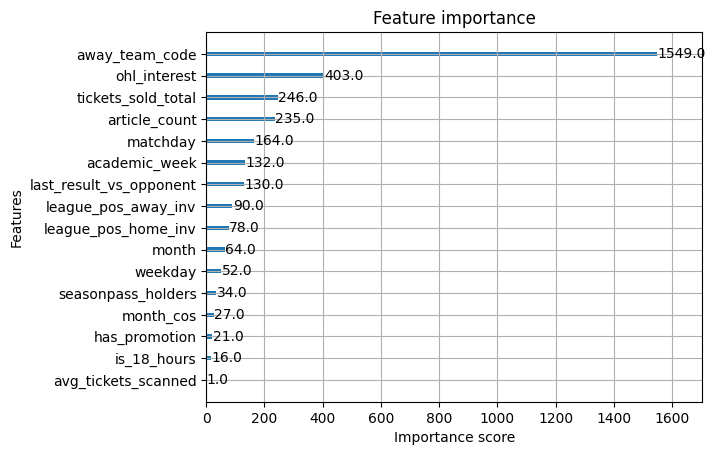

In [348]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(model)
plt.show()

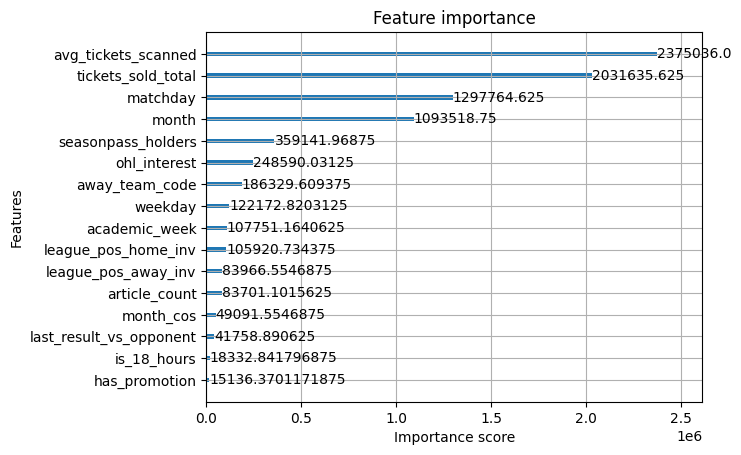

In [349]:
plot_importance(model, importance_type="gain")
plt.show()

In [353]:
# mae
# test_data["tickets_sold_total"]

0     5367
1     6066
2     7749
3     7502
4     8111
5     8549
6     7347
7     7078
8     6278
9     7473
10    6720
11    7355
12    7118
13    7526
Name: tickets_sold_total, dtype: int64